In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import  DNATokenizer

%matplotlib inline

In [ ]:

data_dir="/data/OriDB_random_neg/train_dev_test_oridb50"

data = pd.read_csv(os.path.join(data_dir,"test_window.tsv"), sep='\t', header=0)

print(data.head())


   chr   start     end                                                seq  \
0    9  347365  347864  AGATATTTCAAAGGAGAAGAATTTTTTTAGAAAATATGGTATTACT...   
1   10  653834  654333  CAGATGTGCAATCATGGCCTCTTCTATAGATTTGAAAGGCCCGACT...   
2   16   97994   98493  TTGGTGACGACTAATTGGATTGGGTAGGCCACGAACTCAGAATGTC...   
3   14  177994  178493  ATGAAAAGGTGAGAGAAAATTCAAGAATGATTAACTTGATTAAAGA...   
4    2   70898   71397  TCCATGTACGCCTTGTAATCGATCTCTGTGTAAGCTACCTTCTTAA...   

   label  
0      0  
1      1  
2      0  
3      0  
4      0  


In [ ]:
prob  = np.load("data/OriDB_random_neg/train_dev_test_oridb50/4/test_res/pred_results_model.npy")
Predictions=(prob >= 0.5).astype(int)
data['pred'] = Predictions
data.head

<bound method NDFrame.head of      chr    start      end                                                seq  \
0      9   347365   347864  AGATATTTCAAAGGAGAAGAATTTTTTTAGAAAATATGGTATTACT...   
1     10   653834   654333  CAGATGTGCAATCATGGCCTCTTCTATAGATTTGAAAGGCCCGACT...   
2     16    97994    98493  TTGGTGACGACTAATTGGATTGGGTAGGCCACGAACTCAGAATGTC...   
3     14   177994   178493  ATGAAAAGGTGAGAGAAAATTCAAGAATGATTAACTTGATTAAAGA...   
4      2    70898    71397  TCCATGTACGCCTTGTAATCGATCTCTGTGTAAGCTACCTTCTTAA...   
..   ...      ...      ...                                                ...   
125   10   711379   711878  ATTTAATATACGTAGGGATGCGAGTTATTACATTGGAAATATAGCA...   
126   11    98190    98689  GACGGAGGGGGTGGGAAAAGGCTGAATGCAACCATTGTCACTAAGA...   
127   16    59096    59595  GTACTCAACTGCAATGTAGTGGTTTACCGAACCATTTATGGTTCTC...   
128   11   416581   417080  CAATATCAATCTAATTAGACCGCTCCCAATAGTCACTGTACTAGTA...   
129    4  1252944  1253443  AGAGGTCATTGTTCAAAGTGAGTTGGTGAGTTTTGGTCGGATACCC...  

In [7]:

def format_attention(attention):
    squeezed = []
    for layer_attention in attention:
        # 1 x num_heads x seq_len x seq_len
        if len(layer_attention.shape) != 4:
            raise ValueError("The attention tensor does not have the correct number of dimensions. Make sure you set "
                             "output_attentions=True when initializing your model.")
        squeezed.append(layer_attention.squeeze(0))
    # num_layers x num_heads x seq_len x seq_len
    return torch.stack(squeezed)

def get_attention_dna(model, tokenizer, sentence_a, start, end):
    inputs = tokenizer.encode_plus(sentence_a, sentence_b=None, return_tensors='pt', add_special_tokens=True)
    input_ids = inputs['input_ids']
    output = model(input_ids)
    attention = output[-1]
    logits = output[0]
    pred=logits.detach().numpy()
    softmax = np.exp(pred) / np.sum(np.exp(pred), axis=1, keepdims=True)
    # print("prediction: ")
    # print(pred)
    print("softmax: ", softmax)
    input_id_list = input_ids[0].tolist() # Batch index 0
    tokens = tokenizer.convert_ids_to_tokens(input_id_list) 
    # print("tokens: ", tokens)
    attn = format_attention(attention)
    attn_score = []
    for i in range(1, len(tokens)-1):
        attn_score.append(float(attn[start:end+1,:,0,i].sum()))
    
    matrix_attention_scores = np.zeros([len(tokens), len(tokens)])
    for i in range(0, len(tokens)):
        for j in range(0, len(tokens)):
            matrix_attention_scores[i][j] = float(attn[end,:,i,j].sum())

    return attn_score, matrix_attention_scores

def get_real_score(attention_scores, kmer, metric):
    counts = np.zeros([len(attention_scores)+kmer-1])
    real_scores = np.zeros([len(attention_scores)+kmer-1])

    if metric == "mean":
        for i, score in enumerate(attention_scores):
            for j in range(kmer):
                counts[i+j] += 1.0
                # real_scores[i+j] += score
                real_scores[i+j] += score[0]  # Extract a single element from the score array


        real_scores = real_scores/counts
    else:
        pass

    return real_scores

# SEQUENCE = "TGCCTGGCTTTTTGTAATTTTTGAAGAGACGGGGTTTTGCCATGATG"


In [8]:
def seq2kmer(seq, k):
      
        kmer = [seq[x:x+k] for x in range(len(seq)+1-k)]
        kmers = " ".join(kmer)
        return kmers

In [9]:
def Visualize(kmer, model_path, start_layer, end_layer, metric, sequence):
    
        # load model and calculate attention
    tokenizer_name = 'dna' + str(kmer)
    model_path = model_path
    model = transformers.BertForSequenceClassification.from_pretrained(model_path, output_attentions=True)
    tokenizer = DNATokenizer.from_pretrained(tokenizer_name, do_lower_case=False)
    raw_sentence = sequence 
    sentence_a = seq2kmer(raw_sentence, kmer)
   
   
    attention, atten_matrix = get_attention_dna(model, tokenizer, sentence_a, start=start_layer, end=end_layer)
    
    attention_scores = np.array(attention).reshape(np.array(attention).shape[0],1)
    
    # attention_scores[0] = 0
    
    real_scores = get_real_score(attention_scores, kmer, metric)
    scores = real_scores.reshape(1, real_scores.shape[0])


 
    # plot        
    # sns.set_theme()
    # ax = sns.heatmap(scores, cmap='YlGnBu', vmin=0)
    # plt.show()
    return scores, atten_matrix

    

In [ ]:
original_origin=pd.read_csv("/data/yeast_oridbLess500.csv")
original_origin

,chr,start,end,name,length
0,1,30946,31184,"104,00 ARS",239
1,1,70258,70491,"106,00 ARS",234
2,1,124350,124599,"107,00 ARS",250
3,1,159906,160127,"109,00 ARS",222
4,1,176154,176402,"110,00 ARS",249
...,...,...,...,...,...
320,16,776921,777152,ARS1626.5,232
321,16,819153,819393,"1627,00 ARS",241
322,16,842646,842894,"1628,00 ARS",249
323,16,880854,881102,"1630,00 ARS",249


In [11]:
data['origin_start'] = np.nan
data['origin_end'] = np.nan

for index, row in data.iterrows():
    matching_rows = original_origin[(original_origin['chr'] == row['chr']) & (original_origin['start'] >= row['start']) & (original_origin['end'] <= row['end'])]
    if not matching_rows.empty:
        data.at[index, 'origin_start'] = matching_rows['start'].values[0]
        data.at[index, 'origin_end'] = matching_rows['end'].values[0]

data[data['label']==1].head(10)   

,chr,start,end,seq,label,pred,origin_start,origin_end
1,10,653834,654333,CAGATGTGCAATCATGGCCTCTTCTATAGATTTGAAAGGCCCGACT...,1,0,654069.0,654309.0
6,14,61415,61914,AGAATTCCACGATACAGTAGAAGAGCCTTTCAATTTCACTCGGCAA...,1,1,61597.0,61894.0
8,11,530066,530565,ACCTATTCCTTGGATTATTTATAATATGCATATGCGAGGGCAGAAA...,1,0,530070.0,530560.0
9,15,766442,766941,CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...,1,1,766617.0,766862.0
10,4,1016585,1017084,ACTATGAATTTCACACCATATCCTTATCTAAACGAACTATGGGGTG...,1,1,1016624.0,1016922.0
13,13,183640,184139,TAAATCGCAGAAATCAAATAATATGAAGAGTAAAACAGGTAGATGA...,1,1,183793.0,184037.0
14,5,520711,521210,AATTGCAAATAACGACATTGATAATAATTTACAGTCTTTTTATTTT...,1,1,520767.0,521025.0
16,5,438867,439366,CTTCGAAACTAGTTGAAAAGAGACAAATCCGCTTAATAACTAATAG...,1,1,438929.0,439178.0
17,5,301563,302062,GTTATAGCATGTGCTATTGATAACCCAGAAGCTTGTGAAATGTGTT...,1,1,301565.0,302061.0
18,11,145420,145919,CGAATTAGTTGCCACTCTCATTCCCCACACATAAACTTGTTTTATG...,1,1,145433.0,145893.0


In [12]:
true_positives = data[(data['label'] == 1) & (data['pred'] == 1)]
print(len(true_positives))
filterd=true_positives[true_positives['chr'] == 13]
filterd

51


,chr,start,end,seq,label,pred,origin_start,origin_end
13,13,183640,184139,TAAATCGCAGAAATCAAATAATATGAAGAGTAAAACAGGTAGATGA...,1,1,183793.0,184037.0
66,13,286607,287106,AAAGTTTCTGTAGTGATATTCATTCCTGGTTTGCAGGCATGAAAAG...,1,1,286782.0,287067.0
89,13,468091,468590,TTCACTCCTAATATATCCACCACCGTACCTGATGAAATAAGCAATA...,1,1,468177.0,468468.0


In [28]:
def plot_attention_scores(sample,scores,original_seq=True):
    
    sequence=sample['seq']
        
    start=sample['start']
    end=sample['end']
    if sample['label']==1:
        origin_start=int(sample['origin_start']-start)
        origin_end=  int(sample['origin_end']-start)

    peaks, _ = find_peaks(scores, height=0.2, distance=10)
        
    print("Peaks:", peaks)
       
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(sequence)), scores, marker='o', linestyle='-', color='b', markersize=2)
    plt.xticks(fontsize=16)  # Adjust x-axis numbers
    plt.yticks(fontsize=16)
    if  sample['label']==1:
        plt.axvline(x=origin_start, color='green', linestyle='--', linewidth=2,label='origin start')
        plt.axvline(x=origin_end, color='red', linestyle='--',linewidth=2,label='origin end')

    # plt.xlabel('Position in Sequence',fontsize=14)
    # plt.ylabel('Attention Scores',fontsize=14)
    plt.plot(peaks, scores[peaks], 'x', label='Peaks', color='red', markersize=10, markeredgewidth=4)
    # plt.title("Attention Scores Along DNA Sequence chr{}-{}-{}".format(str(sample['chr']), start, end), fontsize=16)
             
    # plt.legend(fontsize=14)
    plt.show()


chr                                                            13
start                                                      183640
end                                                        184139
seq             TAAATCGCAGAAATCAAATAATATGAAGAGTAAAACAGGTAGATGA...
label                                                           1
pred                                                            1
origin_start                                             183793.0
origin_end                                               184037.0
Name: 13, dtype: object
<class 'transformers.tokenization_dna.DNATokenizer'>
softmax:  [[9.9948716e-01 5.1289424e-04]]
scores: (1, 500)
atten_matrix: (499, 499)
Peaks: [189]


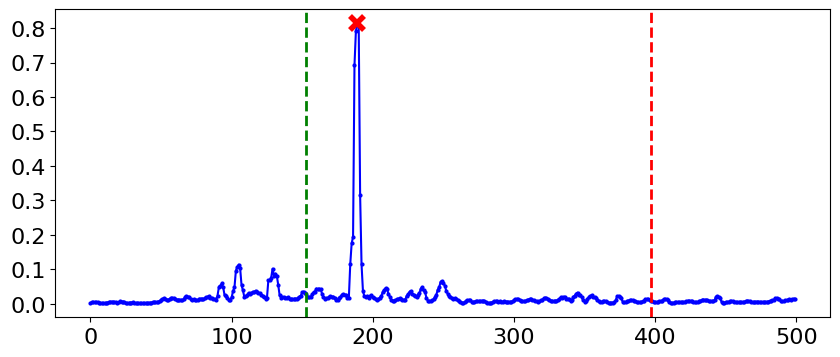

chr                                                            13
start                                                      286607
end                                                        287106
seq             AAAGTTTCTGTAGTGATATTCATTCCTGGTTTGCAGGCATGAAAAG...
label                                                           1
pred                                                            1
origin_start                                             286782.0
origin_end                                               287067.0
Name: 66, dtype: object
<class 'transformers.tokenization_dna.DNATokenizer'>
softmax:  [[0.03615624 0.9638438 ]]
scores: (1, 500)
atten_matrix: (499, 499)
Peaks: [188]


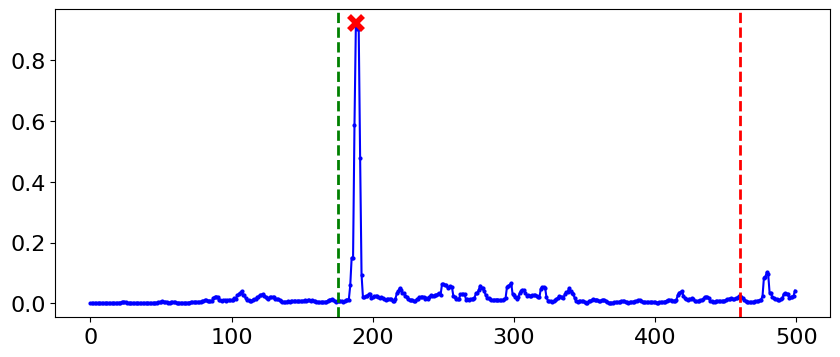

chr                                                            13
start                                                      468091
end                                                        468590
seq             TTCACTCCTAATATATCCACCACCGTACCTGATGAAATAAGCAATA...
label                                                           1
pred                                                            1
origin_start                                             468177.0
origin_end                                               468468.0
Name: 89, dtype: object
<class 'transformers.tokenization_dna.DNATokenizer'>
softmax:  [[3.8637622e-06 9.9999619e-01]]
scores: (1, 500)
atten_matrix: (499, 499)
Peaks: [190 219 277]


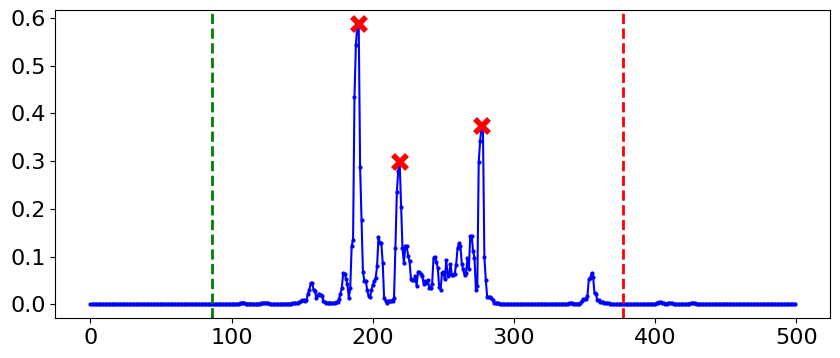

In [ ]:
from scipy.signal import find_peaks
for i in range(3):
    # Set the values for the arguments
    kmer = 4
    model_path = "/data/OriDB_random_neg/train_dev_test_oridb50/4/model"
    start_layer =11
    end_layer = 11
    metric = "mean"
    
    sequence = filterd.iloc[i]
    print(sequence)
    
    
    scores, atten_matrix=Visualize(kmer, model_path, start_layer, end_layer, metric, sequence["seq"])
    print("scores:", scores.shape)
    print("atten_matrix:", atten_matrix.shape)
    attention_scores=scores.reshape(scores.shape[1],)
   
    
    
    
    plot_attention_scores(sequence, scores= attention_scores, original_seq=True) 
    
    
    
    # sns.heatmap(scores,  cmap='viridis', vmin=0)
    # plt.show()
    # sns.heatmap(atten_matrix[0:1, :],  cmap='viridis', vmin=0)
    # plt.show()
    # plt.figure(figsize=(12, 10))
    # sns.heatmap(atten_matrix,  cmap='viridis', vmin=0)
    # plt.xlabel('Tokens')
    # plt.ylabel('Tokens')
    # plt.title("Attention Heatmap for Tokenized Sequence chr{}-{}-{}, by DNABERT".format(str(sequence['chr']), sequence['start'], sequence['end']))
    # plt.show()
